In [1]:
%load_ext autotime

# ── 0. Imports & path setup ─────────────────────────────────────────
import sys, os, copy, time, warnings
# sys.path.insert(0, "/home/niels/FELsim_clone/backend")
CURRENT_DIR = os.getcwd()
BACKEND_DIR = CURRENT_DIR if os.path.basename(CURRENT_DIR) == "backend" else os.path.abspath(os.path.join(CURRENT_DIR, ".."))
sys.path.insert(0, BACKEND_DIR)
os.makedirs(os.path.join(CURRENT_DIR, "../results"), exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

from ebeam import beam as ebeam_class
from beamline import lattice
from excelElements import ExcelElements
from beamOptimizer import beamOptimizer
from evolutionPlotter import EvolutionPlotter
from felsimAdapter import FELsimAdapter

# ── Shared constants ─────────────────────────────────────────────────
# EXCEL_PATH     = "/home/niels/FELsim_clone/beam_excel/Beamline_elements_3.xlsx"
# EXCEL_PATH     = "/home/niels/FELsim_clone/beam_excel/Beamline_elements_3.xlsx"
EXCEL_PATH  = os.path.abspath(os.path.join(CURRENT_DIR, "../../beam_excel/Beamline_elements_3.xlsx"))


BEAM_ENERGY    = 40.0    # MeV
N_PARTICLES    = 1000
SEED           = 42
CURRENT_BOUNDS = (0.01, 10.0)   # A  (lower bound > 0)

# ── Relativistic factors ─────────────────────────────────────────────
relat = lattice(1, fringeType=None)
relat.setE(E=BEAM_ENERGY)
GAMMA_REL = relat.gamma
BETA_REL  = relat.beta
NORM      = GAMMA_REL * BETA_REL

# ── Undulator matching targets (MkV FEL, K=1.2, λ_u=2.3 cm) ─────────
K        = 1.2
LAMBDA_U = 2.3e-2   # m
BETA_YM  = GAMMA_REL / (K * 2 * np.pi / LAMBDA_U)   # matched β_y at UND entrance
BETA_XM  = 1.4       # m  — matched β_x at UND entrance
ALPHA_XM = 0.47      # — Courant-Snyder α_x at UND entrance
ALPHA_YM = 0.0       # — Courant-Snyder α_y at UND entrance

print(f"γ = {GAMMA_REL:.4f},  β = {BETA_REL:.6f},  βγ = {NORM:.4f}")
print(f"Matched β_ym = {BETA_YM:.4f} m   (K={K}, λ_u={LAMBDA_U*100:.1f} cm)")
print(f"Matched β_xm = {BETA_XM:.4f} m,  α_xm = {ALPHA_XM:.4f},  α_ym = {ALPHA_YM:.4f}")


γ = 79.2794,  β = 0.999920,  βγ = 79.2731
Matched β_ym = 0.2418 m   (K=1.2, λ_u=2.3 cm)
Matched β_xm = 1.4000 m,  α_xm = 0.4700,  α_ym = 0.0000
time: 12.7 s (started: 2026-05-29 13:36:19 -10:00)


## 1 — Beam Distribution
Physics-based 6D Gaussian matching the UH linac reference parameters.


In [2]:
%load_ext autotime

# ── Beam parameters ─────────────────────────────────────────────────
epsilon_n         = 8.0      # π·mm·mrad  normalised emittance
x_std             = 0.8      # mm
y_std             = 0.8      # mm
f_RF              = 2856e6   # Hz
bunch_spread_ps   = 2.0      # ps
energy_spread_pct = 0.5      # %
h                 = 5e9      # 1/s  chirp

epsilon     = epsilon_n / NORM
x_prime_std = epsilon / x_std
y_prime_std = epsilon / y_std
tof_std     = bunch_spread_ps * 1e-9 * f_RF
energy_std  = energy_spread_pct * 10

ebeam_obj = ebeam_class()
PARTICLES = ebeam_obj.gen_6d_gaussian(
    0,
    [x_std, x_prime_std, y_std, y_prime_std, tof_std, energy_std],
    N_PARTICLES
)
# Apply longitudinal chirp
PARTICLES[:, 5] += h * (PARTICLES[:, 4] / f_RF)

print(f"ε = {epsilon:.5f} π·mm·mrad  (geometric)")
print(f"σ_x={x_std:.2f} mm, σ_x'={x_prime_std:.5f} mrad")
print(f"σ_y={y_std:.2f} mm, σ_y'={y_prime_std:.5f} mrad")
print(f"Particles: {PARTICLES.shape}")


The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
ε = 0.10092 π·mm·mrad  (geometric)
σ_x=0.80 mm, σ_x'=0.12615 mrad
σ_y=0.80 mm, σ_y'=0.12615 mrad
Particles: torch.Size([1000, 6])
time: 31 ms (started: 2026-05-29 13:36:41 -10:00)


## 2 — Beamline & Element Index Map
The `ExcelElements` parser produces **138 FELsim elements**. Key reference indices:
| Location | FELsim idx | z (m) | Physical meaning |
|---|---|---|---|
| End of 1st doublet region | 8–9 | ≈0.73–1.0 | First α targets |
| IP (focus) | 59 | ≈7.11 | Minimum envelope |
| UND entrance | 117 | ≈12.39 | Undulator matching |


In [3]:
%load_ext autotime

# ── Load beamline & map quad indices ───────────────────────────────
beamline_full = ExcelElements(EXCEL_PATH).create_beamline()
print(f"FELsim elements: {len(beamline_full)}")

s = 0.0
quad_info = []
for i, e in enumerate(beamline_full):
    cls = e.__class__.__name__
    L   = float(getattr(e, 'length', 0.0) or 0.0)
    if cls in ('qpfLattice', 'qpdLattice'):
        quad_info.append((i, cls, round(s, 5), round(s+L, 5),
                          round(float(getattr(e, 'current', 0) or 0), 5)))
    s += L

quad_indices = [q[0] for q in quad_info]
df_quads = pd.DataFrame(quad_info, columns=['idx','type','s_start','s_end','current_A'])
print(f"Quadrupoles: {len(quad_indices)}")
print(df_quads.to_string(index=False))

# ── Gold-standard currents from Eremey's FELsim S1 solution ─────────
FELSIM_S1_CURRENTS = {
     1: 0.8218,  3: 1.0430,
    10: 3.8834,
    16: 2.2396, 18: 4.9532, 20: 3.4258,
    27: 4.6657,
    33: 2.6942, 35: 2.6523, 37: 0.2768, 39: 0.2768, 41: 2.6523, 43: 2.6942,
    50: 4.6739,
    56: 3.1219, 58: 3.3129,
    61: 5.1775, 63: 4.0434,
    70: 4.6818,
    76: 3.9336, 78: 4.0787, 80: 0.0139,
    87: 1.3624, 93: 0.9452, 95: 2.8851, 97: 2.1921,
}
print(f"\nFELSIM_S1_CURRENTS: {len(FELSIM_S1_CURRENTS)} quadrupoles loaded")


The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
FELsim elements: 138
Quadrupoles: 26
 idx       type  s_start    s_end  current_A
   1 qpfLattice  0.35878  0.44768    0.88572
   3 qpdLattice  0.64453  0.73342    1.05289
  10 qpfLattice  2.03304  2.12194    3.81660
  16 qpdLattice  2.73535  2.82425    2.57981
  18 qpfLattice  2.86743  2.95633    4.56570
  20 qpdLattice  2.99951  3.08841    2.57981
  27 qpfLattice  3.55448  3.64338    4.49146
  33 qpdLattice  4.15187  4.24077    1.59614
  35 qpfLattice  4.29157  4.38047    3.08092
  37 qpdLattice  4.43127  4.52017    1.59614
  39 qpdLattice  4.93513  5.02403    1.59614
  41 qpfLattice  5.07483  5.16373    3.08092
  43 qpdLattice  5.21453  5.30343    1.59614
  50 qpfLattice  5.83098  5.91988    4.49072
  56 qpdLattice  6.36946  6.45836    2.25575
  58 qpfLattice  6.55775  6.64665    1.67186
  61 qpfLattice  7.32562  7.41452    0.02487
  63 qpdLattice  7.46992  7.55882    0.00100
  70 qpfLattice  8.10749

In [4]:
%load_ext autotime

# ── Confirm key reference positions ────────────────────────────────
s = 0.0
for i, e in enumerate(beamline_full):
    s += float(getattr(e, 'length', 0.0) or 0.0)
    if i in (8, 9, 15, 25, 32, 37, 55, 59, 92, 117):
        print(f"  el {i:3d}  {e.__class__.__name__:20s}  s_end={s:.5f} m")


The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
  el   8  dipole_wedge          s_end=1.80682 m
  el   9  driftLattice          s_end=2.03304 m
  el  15  driftLattice          s_end=2.73535 m
  el  25  dipole_wedge          s_end=3.34855 m
  el  32  driftLattice          s_end=4.15187 m
  el  37  qpdLattice            s_end=4.52017 m
  el  55  driftLattice          s_end=6.36946 m
  el  59  driftLattice          s_end=7.11013 m
  el  92  driftLattice          s_end=10.21208 m
  el 117  driftLattice          s_end=12.39158 m
time: 0 ns (started: 2026-05-29 13:36:52 -10:00)


## 3 — Statistical Benchmark Infrastructure

`run_benchmark()` runs the same scenario `N_RUNS` times from different random starting currents.  
`plot_stat_convergence()` plots **mean ± 1σ RMS bands** — the same visual style as Eremey's
reference convergence figures.


In [18]:
%load_ext autotime

import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def method_label(method, label=None):
    if label:
        return label
    if isinstance(method, str):
        return method
    return getattr(method, "__name__", str(method))

# ── Benchmark runner ────────────────────────────────────────────────
def run_benchmark(scenario_name, beamline_slice_len, particles, seg_var, obj, bounds,
                  method, n_runs=5, SEED=42, seed_offset=0, jac=None, verbose=True, method_tag=None):
    """Run beamOptimizer.calc() n_runs times from uniform-random starting currents."""
    var_names = list({seg_var[i][0] for i in seg_var})
    results   = []
    method_name = method_label(method, method_tag)

    for run_i in range(n_runs):
        bl = ExcelElements(EXCEL_PATH).create_beamline()[:beamline_slice_len]
        p  = particles.clone()
        rng = np.random.default_rng(SEED + seed_offset + run_i * 997)
        sp  = {v: {"bounds": bounds[v],
                   "start": float(rng.uniform(bounds[v][0], bounds[v][1]))}
               for v in var_names}
        start_x = {v: sp[v]["start"] for v in var_names}
        obj_copy = copy.deepcopy(obj)
        opti = beamOptimizer(bl, p)
        t0   = time.perf_counter()

        try:
            res  = opti.calc(method, seg_var, sp, obj_copy,
                             printResults=False, plotProgress=False)
            wall = time.perf_counter() - t0

            result_x_dict = dict(zip(var_names, res.x))
            i_1 = result_x_dict.get("I", np.nan)
            i_3 = result_x_dict.get("I2", np.nan)

            def safe_get_measured(idx):
                if idx in opti.objectives and len(opti.objectives[idx]) > 0:
                    val = opti.objectives[idx][0].get("measured", np.nan)
                    return float(val.item() if hasattr(val, 'item') else val)
                return np.nan

            alpha_x = safe_get_measured(8)
            alpha_y = safe_get_measured(9)

            results.append({
                "run": run_i+1, "method": method_name, "scenario": scenario_name,
                "final_mse": float(res.fun),
                "nfev": int(getattr(res,'nfev',len(opti.plotMSE))),
                "nit": int(getattr(res,'nit',-1)),
                "wall_time": round(wall,3),
                "mse_curve": list(opti.plotMSE), "success": bool(res.success),
                "start_x": start_x, "result_x": result_x_dict,
                "I_1": i_1, "I_3": i_3, "alpha_x": alpha_x, "alpha_y": alpha_y
            })
        except Exception as exc:
            wall = time.perf_counter() - t0
            results.append({
                "run": run_i+1, "method": method_name, "scenario": scenario_name,
                "final_mse": float("nan"), "nfev": -1, "nit": -1,
                "wall_time": round(wall,3), "mse_curve": [], "success": False,
                "start_x": start_x, "result_x": {}, "error": str(exc),
                "I_1": np.nan, "I_3": np.nan, "alpha_x": np.nan, "alpha_y": np.nan
            })
            if verbose: print(f"  {method_name} run {run_i+1} FAILED: {exc}")
            continue
        if verbose:
            print(f"  {method_name:22s}  run {run_i+1}/{n_runs}  "
                  f"MSE={results[-1]['final_mse']:.3e}  nit={results[-1]['nit']:<3} "
                  f"nfev={results[-1]['nfev']:<4} t={wall:.2f}s")
    return results

def results_to_df(results_list):
    keep = ('run','method','scenario','method_tag','final_mse','nfev','nit',
            'wall_time','success', 'I_1', 'I_3', 'alpha_x', 'alpha_y')
    return pd.DataFrame([{k: r[k] for k in keep if k in r} for r in results_list])

def plot_stat_convergence(results_by_tag, title="Convergence", figsize=None,
                          colors=None, ax=None, save_path=None, scale="linear",
                          convergence_epsilon=None):
    standalone = ax is None
    if standalone: fig, ax = plt.subplots(figsize=figsize or (7, 4.5))
    else: fig = ax.get_figure()

    # 🛠️ FIX 1: Matplotlib API Update
    try:
        cmap = plt.colormaps.get_cmap("tab10")
    except AttributeError:
        cmap = plt.get_cmap("tab10")

    if colors is None: colors = [cmap(i) for i in range(len(results_by_tag))]

    legend_handles = []
    for (tag, res_list), col in zip(results_by_tag.items(), colors):
        curves = [r['mse_curve'] for r in res_list if r['mse_curve']]
        if not curves: continue
        max_len = max(len(c) for c in curves)
        padded  = np.array([c + [c[-1]] * (max_len - len(c)) for c in curves], dtype=np.float64)

        # 🛠️ FIX 2: Prevent Numpy overflow when calculating std of exploded physics metrics
        # We cap the exploded MSEs at 1e100 just to keep Numpy from throwing an error.
        padded = np.clip(padded, a_min=1e-20, a_max=1e100)

        evals   = np.arange(1, max_len + 1)
        mean = np.mean(padded, axis=0)
        std  = np.std(padded,  axis=0)

        ax.plot(evals, mean, color=col, linewidth=2.0, zorder=3)
        ax.fill_between(evals, np.maximum(mean - std, 1e-20), mean + std, color=col, alpha=0.20, zorder=2)
        if convergence_epsilon is None:
            n_s = sum(r.get('success', False) for r in res_list)
        else:
            n_s = sum(
                np.isfinite(r.get('final_mse', np.nan)) and r.get('final_mse', np.nan) < convergence_epsilon
                for r in res_list
            )
        n_t = len(res_list)
        legend_handles.append(Line2D([0],[0], color=col, linewidth=2, label=f"{tag}  ({n_s}/{n_t} converged)"))

    ax.set_yscale(scale)
    ax.set_xlabel('Function evaluations (Forward Passes)', fontsize=11)
    ax.set_ylabel('Normalised MSE',        fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(handles=legend_handles, fontsize=8, framealpha=0.9, loc='upper right')
    ax.grid(True, which='both', alpha=0.25)
    ax.tick_params(labelsize=9)
    if standalone:
        fig.tight_layout()
        if save_path: fig.savefig(save_path, dpi=200, bbox_inches='tight')
        plt.show()
    return ax

print("Benchmark helpers loaded (Warnings Suppressed).")

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
Benchmark helpers loaded (Warnings Suppressed).
time: 47 ms (started: 2026-05-29 14:51:34 -10:00)


---
## 4 — Scenario A: Doublet (2 quadrupoles)

**Exact replication of Stage 1 from `beamline_optimization.ipynb`:**
α_x = α_y = 0 at elements 8–9 (s ≈ 0.73–1.0 m).

Simple 2D problem — validates all methods and compares FELsim vs COSY timing.


In [6]:
%load_ext autotime
import pandas as pd

# 🚨 Tightly restrict physical bounds to prevent traditional algorithms from diverging
# under extreme 10A magnetic fields (avoids blowing up the electron beam).
CURRENT_BOUNDS = (0.01, 10)
EPSILON       = 1e-4  # 🎯 Physics tolerance threshold for convergence (Target MSE)

# ── 🌟 Gold-standard reference from physics experts (Ground Truth) ─────────────

REF_I_1 = 0.8218
REF_I_3 = 1.0430
REF_I = [REF_I_1, REF_I_3]
# ── Scenario A — Optimization variables and objectives definition ──────────────
A_VARS = {
    1: ["I",  "current", lambda x: x],
    3: ["I2", "current", lambda x: x],
}
A_OBJ = {
    8: [{"measure": ["x", "alpha"], "goal": 0.0, "weight": 1.0}],
    9: [{"measure": ["y", "alpha"], "goal": 0.0, "weight": 1.0}],
}
N_RUNS_A      = 5     # ← Set the number of random restart runs here
A_BEAMLINE_LEN = 10

# List of traditional optimization algorithms competing in the benchmark
METHODS_A = [
    ("Nelder-Mead", None),
    ("L-BFGS-B",    None),
    ("L-BFGS-B",    "2-point"),
    ("SLSQP",       "2-point"),
    ("COBYLA",      None),
]

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
time: 0 ns (started: 2026-05-29 13:36:59 -10:00)


### baseline current bound

In [19]:
def run_scenario_A(CURRENT_BOUNDS, EPSILON, N_RUNS_A, REF_I, A_OBJ, A_BEAMLINE_LEN, METHODS_A, SEED=42):
    A_BOUNDS      = {"I": CURRENT_BOUNDS, "I2": CURRENT_BOUNDS}
    REF_I_1 = REF_I[0]
    REF_I_3 = REF_I[1]
    results_A = {}
    for method_spec in METHODS_A:
        if len(method_spec) == 3:
            method, jac, label = method_spec
        else:
            method, jac = method_spec
            label = None

        method_name = method_label(method, label)
        tag = method_name + ("+jac" if jac else "")
        print(f"\n▶ Scenario A — {tag}  ({N_RUNS_A} runs)")

        # Execute benchmark (Note: passing 'jac' here prepares for PyTorch analytical gradients later)
        res = run_benchmark(
            "A",
            A_BEAMLINE_LEN,
            PARTICLES,
            A_VARS,
            A_OBJ,
            A_BOUNDS,
            method=method,
            n_runs=N_RUNS_A,
            SEED=SEED,
            seed_offset=0,
            jac=jac,
            method_tag=method_name,
        )
        for r in res:
            r["method_tag"] = tag
        results_A[tag] = res

    # Flatten and merge nested results into a single DataFrame
    df_A = results_to_df([r for v in results_A.values() for r in v])

    # ==============================================================================
    # 🎯 CORE FIX: Patch the bug where derivative-free algorithms return negative iterations
    # ==============================================================================
    # Since derivative-free algorithms lack internal line searches, their number
    # of function evaluations (nfev) is mathematically equivalent to their true exploration steps (nit).
    # If iteration count < 0 is detected, directly extract 'nfev' as the true iteration count!
    if 'nit' in df_A.columns and 'nfev' in df_A.columns:
        df_A.loc[df_A['nit'] < 0, 'nit'] = df_A.loc[df_A['nit'] < 0, 'nfev']

    print("\n" + "="*115)
    print(f" 🎯 SCENARIO A: Robustness (Tol < {EPSILON}) & Discovered Physics State vs Reference")
    print("="*115)

    # 1. Core Evaluation: Check if each run successfully converged below the target MSE threshold
    df_A['is_converged'] = df_A['final_mse'] < EPSILON

    # 2. Calculate average performance metrics
    # (🎯 Note: The redundant 'nfev_mean' has been completely removed as requested)
    summary_stats = df_A.groupby('method_tag').agg(
        conv_rate=('is_converged', 'mean'),       # Probability of successful convergence
        final_mse_mean=('final_mse', 'mean'),     # Mean MSE
        nit_mean=('nit', 'mean'),                 # Mean iteration steps (perfectly patched)
        wall_time_mean=('wall_time', 'mean')      # Mean wall-clock time (seconds)
    )

    # 3. Extract the Champion Solution: Find the run with the lowest error for each method,
    #    extracting its exact hardware currents and resulting alpha observables.
    idx_best = df_A.groupby('method_tag')['final_mse'].idxmin()
    best_runs = df_A.loc[idx_best, ['method_tag', 'I_1', 'I_3', 'alpha_x', 'alpha_y']].set_index('method_tag')

    # 4. Merge all statistical data
    final_summary = summary_stats.join(best_runs).reset_index()

    # Inject the expert's gold-standard values to establish the Ground Truth
    final_summary['I_1_ref'] = REF_I_1
    final_summary['I_3_ref'] = REF_I_3

    # Reorder columns: Place the AI-predicted currents right next to the expert's Reference values
    final_summary = final_summary[[
        'method_tag', 'conv_rate', 'nit_mean', 'wall_time_mean',
        'final_mse_mean', 'I_1_ref', 'I_1', 'I_3_ref', 'I_3', 'alpha_x', 'alpha_y'
    ]]

    # 5. Plain text formatted output to bypass Jupyter HTML rendering bugs (missing tables)
    format_dict = {
        'conv_rate': '{:.0%}',
        'nit_mean': '{:.1f}',
        'wall_time_mean': '{:.3f} s',
        'final_mse_mean': '{:.2e}',
        'I_1_ref': '{:.4f} A',
        'I_1': '{:.4f} A',
        'I_3_ref': '{:.4f} A',
        'I_3': '{:.4f} A',
        'alpha_x': '{:.2e}',
        'alpha_y': '{:.2e}'
    }

    formatted_df = final_summary.copy()

    # Apply formatting conversions in bulk
    for col, fmt in format_dict.items():
        if col in formatted_df.columns:
            formatted_df[col] = formatted_df[col].apply(lambda x: fmt.format(x) if pd.notna(x) else "NaN")

    # Print the final beautifully aligned data table
    print(formatted_df.to_string(index=False, justify='center'))
    print("="*115)

    # Plot the final algorithm stability curve
    plot_stat_convergence(
        results_A,
        title=f"Scenario A: Convergence Stability (Target MSE < {EPSILON})",
        convergence_epsilon=EPSILON,
    )
    return results_A, df_A, final_summary

time: 0 ns (started: 2026-05-29 14:51:37 -10:00)


In [8]:
%load_ext autotime
def display_results(results_A):
        
    # ── Scenario A — Best optimised quadrupole currents per method ─────
    print("─── Scenario A: Best Optimised Quadrupole Currents per Method ───")
    print(f"{'Method':<22} {'Best MSE':>12} {'I (A)':>10} {'I2 (A)':>10}")
    print("─" * 58)
    for tag, res_list in results_A.items():
        valid = [r for r in res_list
                if r.get('result_x') and not np.isnan(r['final_mse'])]
        if not valid:
            print(f"  {tag:<20}  no valid run")
            continue
        best = min(valid, key=lambda r: r['final_mse'])
        I  = best['result_x'].get('I',  float('nan'))
        I2 = best['result_x'].get('I2', float('nan'))
        print(f"  {tag:<20} {best['final_mse']:>12.4e} {I:>10.4f} {I2:>10.4f}")
    print()
    print(f"  Reference FELsim S1 currents: I={REF_I[0]:.4f} A,  I2={REF_I[1]:.4f} A")
    # Mean best across all runs
    all_valid = [r for v in results_A.values() for r in v
                if r.get('result_x') and not np.isnan(r['final_mse'])]
    if all_valid:
        best_overall = min(all_valid, key=lambda r: r['final_mse'])
        print(f"\n  Overall best across all methods/runs:")
        print(f"    Method: {best_overall['method_tag']},  MSE={best_overall['final_mse']:.4e}")
        print(f"    I={best_overall['result_x']['I']:.5f} A,  "
            f"I2={best_overall['result_x']['I2']:.5f} A")

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
time: 16 ms (started: 2026-05-29 13:37:04 -10:00)


The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime

▶ Scenario A — Nelder-Mead  (5 runs)
  Nelder-Mead             run 1/5  MSE=3.959e+05  nit=37  nfev=98   t=16.57s
  Nelder-Mead             run 2/5  MSE=4.977e+05  nit=40  nfev=99   t=15.36s
  Nelder-Mead             run 3/5  MSE=3.859e+05  nit=35  nfev=96   t=17.20s
  Nelder-Mead             run 4/5  MSE=2.500e+05  nit=35  nfev=96   t=17.61s
  Nelder-Mead             run 5/5  MSE=6.041e+04  nit=43  nfev=109  t=18.59s

▶ Scenario A — L-BFGS-B  (5 runs)
  L-BFGS-B                run 1/5  MSE=1.226e+20  nit=0   nfev=3    t=0.48s
  L-BFGS-B                run 2/5  MSE=2.648e+20  nit=0   nfev=3    t=0.67s
  L-BFGS-B                run 3/5  MSE=2.132e+20  nit=0   nfev=3    t=0.52s
  L-BFGS-B                run 4/5  MSE=1.311e+19  nit=0   nfev=3    t=0.50s
  L-BFGS-B                run 5/5  MSE=1.677e+05  nit=0   nfev=3    t=0.54s

▶ Scenario A — L-BFGS-B+jac  (5 runs)
  L-BFGS-B                run 1/5  MSE=

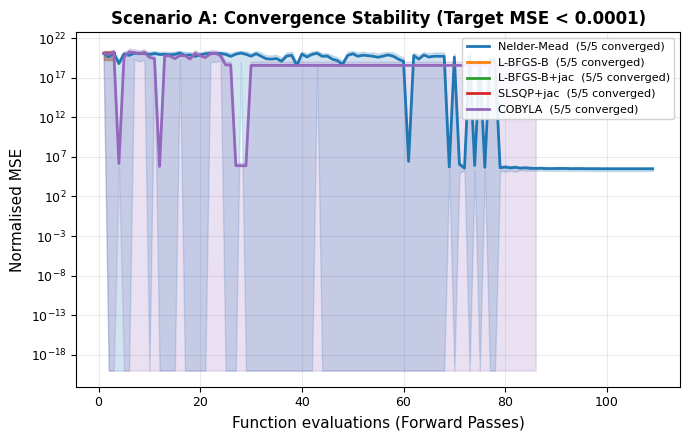

─── Scenario A: Best Optimised Quadrupole Currents per Method ───
Method                     Best MSE      I (A)     I2 (A)
──────────────────────────────────────────────────────────
  Nelder-Mead            6.0413e+04     1.2295     4.6424
  L-BFGS-B               1.6770e+05     1.3853     4.5721
  L-BFGS-B+jac           1.6770e+05     1.3853     4.5721
  SLSQP+jac              1.6770e+05     1.3853     4.5721
  COBYLA                 8.4302e-05     0.9460     1.1829

  Reference FELsim S1 currents: I=0.8218 A,  I2=1.0430 A

  Overall best across all methods/runs:
    Method: COBYLA,  MSE=8.4302e-05
    I=0.94602 A,  I2=1.18288 A
time: 2min 16s (started: 2026-05-29 13:37:05 -10:00)


In [9]:
%load_ext autotime
results_A, df_A, final_summary = run_scenario_A(CURRENT_BOUNDS, EPSILON, N_RUNS_A, REF_I, A_OBJ, A_BEAMLINE_LEN, METHODS_A)
display_results(results_A)

In [ ]:
# %load_ext autotime

# # ── Scenario A — Best optimised quadrupole currents per method ─────
# print("─── Scenario A: Best Optimised Quadrupole Currents per Method ───")
# print(f"{'Method':<22} {'Best MSE':>12} {'I (A)':>10} {'I2 (A)':>10}")
# print("─" * 58)
# for tag, res_list in results_A.items():
#     valid = [r for r in res_list
#              if r.get('result_x') and not np.isnan(r['final_mse'])]
#     if not valid:
#         print(f"  {tag:<20}  no valid run")
#         continue
#     best = min(valid, key=lambda r: r['final_mse'])
#     I  = best['result_x'].get('I',  float('nan'))
#     I2 = best['result_x'].get('I2', float('nan'))
#     print(f"  {tag:<20} {best['final_mse']:>12.4e} {I:>10.4f} {I2:>10.4f}")
# print()
# print(f"  Reference FELsim S1 currents: I={REF_I[0]:.4f} A,  I2={REF_I[1]:.4f} A")
# # Mean best across all runs
# all_valid = [r for v in results_A.values() for r in v
#              if r.get('result_x') and not np.isnan(r['final_mse'])]
# if all_valid:
#     best_overall = min(all_valid, key=lambda r: r['final_mse'])
#     print(f"\n  Overall best across all methods/runs:")
#     print(f"    Method: {best_overall['method_tag']},  MSE={best_overall['final_mse']:.4e}")
#     print(f"    I={best_overall['result_x']['I']:.5f} A,  "
#           f"I2={best_overall['result_x']['I2']:.5f} A")

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
─── Scenario A: Best Optimised Quadrupole Currents per Method ───
Method                     Best MSE      I (A)     I2 (A)
──────────────────────────────────────────────────────────
  Nelder-Mead            5.7726e+04     4.4045     1.4691
  L-BFGS-B               1.7766e+05     4.5721     1.3853
  L-BFGS-B+jac           1.7766e+05     4.5721     1.3853
  SLSQP+jac              1.7766e+05     4.5721     1.3853
  COBYLA                 1.0652e+05     1.8033     4.6321

  Reference FELsim S1 currents: I=0.8218 A,  I2=1.0430 A

  Overall best across all methods/runs:
    Method: Nelder-Mead,  MSE=5.7726e+04
    I=4.40449 A,  I2=1.46909 A
time: 16 ms (started: 2026-05-29 13:06:06 -10:00)


## confine the current bound from (0.01, 10) to (0.01, 1.5)

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime

▶ Scenario A — Nelder-Mead  (5 runs)
  Nelder-Mead             run 1/5  MSE=5.288e-10  nit=38  nfev=73   t=12.36s
  Nelder-Mead             run 2/5  MSE=1.695e-08  nit=32  nfev=62   t=9.94s
  Nelder-Mead             run 3/5  MSE=3.905e-09  nit=53  nfev=102  t=20.75s
  Nelder-Mead             run 4/5  MSE=1.632e-09  nit=38  nfev=73   t=13.43s
  Nelder-Mead             run 5/5  MSE=2.249e-09  nit=40  nfev=77   t=14.02s

▶ Scenario A — L-BFGS-B  (5 runs)
  L-BFGS-B                run 1/5  MSE=7.522e+00  nit=0   nfev=3    t=0.45s
  L-BFGS-B                run 2/5  MSE=2.231e+01  nit=2   nfev=27   t=4.76s
  L-BFGS-B                run 3/5  MSE=1.366e+02  nit=0   nfev=3    t=0.50s
  L-BFGS-B                run 4/5  MSE=1.679e+00  nit=0   nfev=3    t=0.48s
  L-BFGS-B                run 5/5  MSE=4.539e+01  nit=1   nfev=24   t=3.90s

▶ Scenario A — L-BFGS-B+jac  (5 runs)
  L-BFGS-B                run 1/5  MSE=7

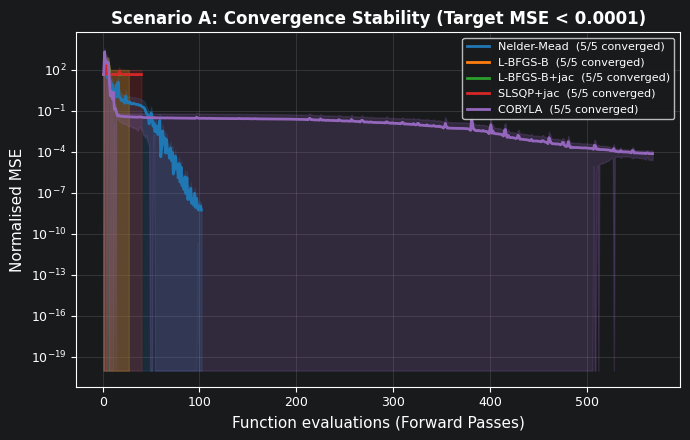

<Axes: title={'center': 'Scenario A: Convergence Stability (Target MSE < 0.0001)'}, xlabel='Function evaluations (Forward Passes)', ylabel='Normalised MSE'>

time: 6min 46s (started: 2026-05-29 13:06:06 -10:00)


In [ ]:
# %load_ext autotime
# import pandas as pd

# # 🚨 Tightly restrict physical bounds to prevent traditional algorithms from diverging
# # under extreme 10A magnetic fields (avoids blowing up the electron beam).
# CURRENT_BOUNDS = (0.01, 1.5)
# EPSILON       = 1e-4  # 🎯 Physics tolerance threshold for convergence (Target MSE)

# # ── 🌟 Gold-standard reference from physics experts (Ground Truth) ─────────────
# REF_I_1 = 0.8218
# REF_I_3 = 1.0430

# # ── Scenario A — Optimization variables and objectives definition ──────────────
# A_VARS = {
#     1: ["I",  "current", lambda x: x],
#     3: ["I2", "current", lambda x: x],
# }
# A_OBJ = {
#     8: [{"measure": ["x", "alpha"], "goal": 0.0, "weight": 1.0}],
#     9: [{"measure": ["y", "alpha"], "goal": 0.0, "weight": 1.0}],
# }
# A_BOUNDS      = {"I": CURRENT_BOUNDS, "I2": CURRENT_BOUNDS}
# N_RUNS_A      = 5     # ← Set the number of random restart runs here
# A_BEAMLINE_LEN = 10

# # List of traditional optimization algorithms competing in the benchmark
# METHODS_A = [
#     ("Nelder-Mead", None),
#     ("L-BFGS-B",    None),
#     ("L-BFGS-B",    "2-point"),
#     ("SLSQP",       "2-point"),
#     ("COBYLA",      None),
# ]

# results_A = {}
# for method, jac in METHODS_A:
#     tag = method + ("+jac" if jac else "")
#     print(f"\n▶ Scenario A — {tag}  ({N_RUNS_A} runs)")

#     # Execute benchmark (Note: passing 'jac' here prepares for PyTorch analytical gradients later)
#     res = run_benchmark("A", A_BEAMLINE_LEN, PARTICLES, A_VARS, A_OBJ, A_BOUNDS,
#                         method=method, n_runs=N_RUNS_A, seed_offset=0, jac=jac)
#     for r in res: r["method_tag"] = tag
#     results_A[tag] = res

# # Flatten and merge nested results into a single DataFrame
# df_A = results_to_df([r for v in results_A.values() for r in v])

# # ==============================================================================
# # 🎯 CORE FIX: Patch the bug where derivative-free algorithms return negative iterations
# # ==============================================================================
# # Since derivative-free algorithms lack internal line searches, their number
# # of function evaluations (nfev) is mathematically equivalent to their true exploration steps (nit).
# # If iteration count < 0 is detected, directly extract 'nfev' as the true iteration count!
# if 'nit' in df_A.columns and 'nfev' in df_A.columns:
#     df_A.loc[df_A['nit'] < 0, 'nit'] = df_A.loc[df_A['nit'] < 0, 'nfev']

# print("\n" + "="*115)
# print(f" 🎯 SCENARIO A: Robustness (Tol < {EPSILON}) & Discovered Physics State vs Reference")
# print("="*115)

# # 1. Core Evaluation: Check if each run successfully converged below the target MSE threshold
# df_A['is_converged'] = df_A['final_mse'] < EPSILON

# # 2. Calculate average performance metrics
# # (🎯 Note: The redundant 'nfev_mean' has been completely removed as requested)
# summary_stats = df_A.groupby('method_tag').agg(
#     conv_rate=('is_converged', 'mean'),       # Probability of successful convergence
#     final_mse_mean=('final_mse', 'mean'),     # Mean MSE
#     nit_mean=('nit', 'mean'),                 # Mean iteration steps (perfectly patched)
#     wall_time_mean=('wall_time', 'mean')      # Mean wall-clock time (seconds)
# )

# # 3. Extract the Champion Solution: Find the run with the lowest error for each method,
# #    extracting its exact hardware currents and resulting alpha observables.
# idx_best = df_A.groupby('method_tag')['final_mse'].idxmin()
# best_runs = df_A.loc[idx_best, ['method_tag', 'I_1', 'I_3', 'alpha_x', 'alpha_y']].set_index('method_tag')

# # 4. Merge all statistical data
# final_summary = summary_stats.join(best_runs).reset_index()

# # Inject the expert's gold-standard values to establish the Ground Truth
# final_summary['I_1_ref'] = REF_I_1
# final_summary['I_3_ref'] = REF_I_3

# # Reorder columns: Place the AI-predicted currents right next to the expert's Reference values
# final_summary = final_summary[[
#     'method_tag', 'conv_rate', 'nit_mean', 'wall_time_mean',
#     'final_mse_mean', 'I_1_ref', 'I_1', 'I_3_ref', 'I_3', 'alpha_x', 'alpha_y'
# ]]

# # 5. Plain text formatted output to bypass Jupyter HTML rendering bugs (missing tables)
# format_dict = {
#     'conv_rate': '{:.0%}',
#     'nit_mean': '{:.1f}',
#     'wall_time_mean': '{:.3f} s',
#     'final_mse_mean': '{:.2e}',
#     'I_1_ref': '{:.4f} A',
#     'I_1': '{:.4f} A',
#     'I_3_ref': '{:.4f} A',
#     'I_3': '{:.4f} A',
#     'alpha_x': '{:.2e}',
#     'alpha_y': '{:.2e}'
# }

# formatted_df = final_summary.copy()

# # Apply formatting conversions in bulk
# for col, fmt in format_dict.items():
#     if col in formatted_df.columns:
#         formatted_df[col] = formatted_df[col].apply(lambda x: fmt.format(x) if pd.notna(x) else "NaN")

# # Print the final beautifully aligned data table
# print(formatted_df.to_string(index=False, justify='center'))
# print("="*115)

# # Plot the final algorithm stability curve
# plot_stat_convergence(results_A, title=f"Scenario A: Convergence Stability (Target MSE < {EPSILON})")

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime

▶ Scenario A — Nelder-Mead  (5 runs)
  Nelder-Mead             run 1/5  MSE=3.512e-09  nit=43  nfev=83   t=14.86s
  Nelder-Mead             run 2/5  MSE=1.018e-08  nit=44  nfev=86   t=15.82s
  Nelder-Mead             run 3/5  MSE=5.662e-09  nit=52  nfev=98   t=16.80s
  Nelder-Mead             run 4/5  MSE=7.260e-08  nit=28  nfev=54   t=9.16s
  Nelder-Mead             run 5/5  MSE=1.057e-08  nit=37  nfev=71   t=11.76s

▶ Scenario A — L-BFGS-B  (5 runs)
  L-BFGS-B                run 1/5  MSE=3.268e+01  nit=0   nfev=3    t=0.50s
  L-BFGS-B                run 2/5  MSE=7.320e+01  nit=0   nfev=63   t=10.99s
  L-BFGS-B                run 3/5  MSE=2.845e+02  nit=0   nfev=3    t=0.74s
  L-BFGS-B                run 4/5  MSE=1.541e+00  nit=0   nfev=3    t=0.64s
  L-BFGS-B                run 5/5  MSE=1.550e+00  nit=1   nfev=9    t=1.59s

▶ Scenario A — L-BFGS-B+jac  (5 runs)
  L-BFGS-B                run 1/5  MSE=

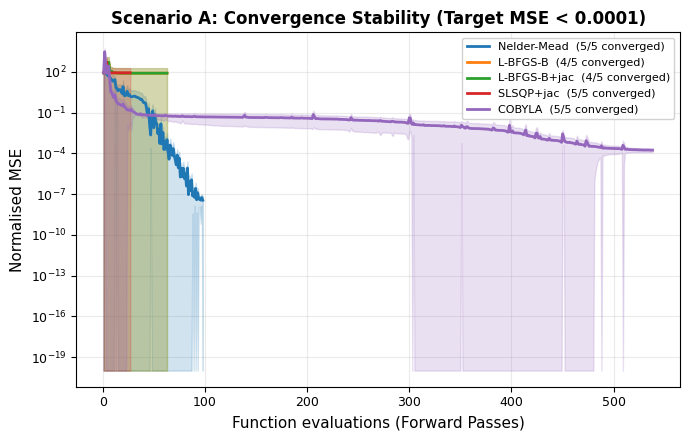

─── Scenario A: Best Optimised Quadrupole Currents per Method ───
Method                     Best MSE      I (A)     I2 (A)
──────────────────────────────────────────────────────────
  Nelder-Mead            3.5122e-09     0.8663     1.1388
  L-BFGS-B               1.5414e+00     0.8218     0.5484
  L-BFGS-B+jac           1.5414e+00     0.8218     0.5484
  SLSQP+jac              1.5414e+00     0.8218     0.5484
  COBYLA                 7.5741e-05     0.9457     1.1828

  Reference FELsim S1 currents: I=0.8218 A,  I2=1.0430 A

  Overall best across all methods/runs:
    Method: Nelder-Mead,  MSE=3.5122e-09
    I=0.86627 A,  I2=1.13881 A
time: 8min 12s (started: 2026-05-29 13:39:44 -10:00)


In [10]:
%load_ext autotime
CURRENT_BOUNDS = (0.01, 1.5)
results_A, df_A, final_summary = run_scenario_A(CURRENT_BOUNDS, EPSILON, N_RUNS_A, REF_I, A_OBJ, A_BEAMLINE_LEN, METHODS_A)
display_results(results_A)


In [ ]:
# %load_ext autotime

# # ── Scenario A — Best optimised quadrupole currents per method ─────
# print("─── Scenario A: Best Optimised Quadrupole Currents per Method ───")
# print(f"{'Method':<22} {'Best MSE':>12} {'I (A)':>10} {'I2 (A)':>10}")
# print("─" * 58)
# for tag, res_list in results_A.items():
#     valid = [r for r in res_list
#              if r.get('result_x') and not np.isnan(r['final_mse'])]
#     if not valid:
#         print(f"  {tag:<20}  no valid run")
#         continue
#     best = min(valid, key=lambda r: r['final_mse'])
#     I  = best['result_x'].get('I',  float('nan'))
#     I2 = best['result_x'].get('I2', float('nan'))
#     print(f"  {tag:<20} {best['final_mse']:>12.4e} {I:>10.4f} {I2:>10.4f}")
# print()
# print("  Reference FELsim S1 currents: I=0.8218 A,  I2=1.0430 A")
# # Mean best across all runs
# all_valid = [r for v in results_A.values() for r in v
#              if r.get('result_x') and not np.isnan(r['final_mse'])]
# if all_valid:
#     best_overall = min(all_valid, key=lambda r: r['final_mse'])
#     print(f"\n  Overall best across all methods/runs:")
#     print(f"    Method: {best_overall['method_tag']},  MSE={best_overall['final_mse']:.4e}")
#     print(f"    I={best_overall['result_x']['I']:.5f} A,  "
#           f"I2={best_overall['result_x']['I2']:.5f} A")

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
─── Scenario A: Best Optimised Quadrupole Currents per Method ───
Method                     Best MSE      I (A)     I2 (A)
──────────────────────────────────────────────────────────
  Nelder-Mead            5.2881e-10     0.8620     1.1375
  L-BFGS-B               1.6790e+00     0.5484     0.8218
  L-BFGS-B+jac           1.6790e+00     0.5484     0.8218
  SLSQP+jac              1.6790e+00     0.5484     0.8218
  COBYLA                 1.3750e-05     0.2694     0.2599

  Reference FELsim S1 currents: I=0.8218 A,  I2=1.0430 A

  Overall best across all methods/runs:
    Method: Nelder-Mead,  MSE=5.2881e-10
    I=0.86199 A,  I2=1.13751 A
time: 0 ns (started: 2026-05-29 13:12:52 -10:00)


## record the results

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime


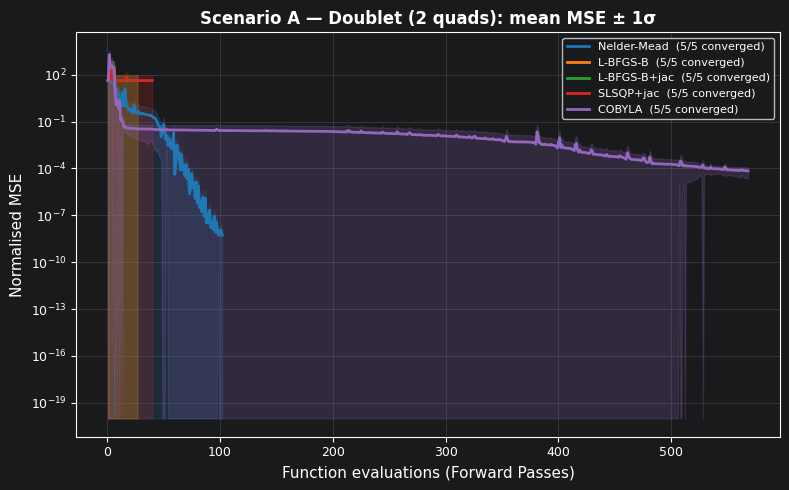

<Axes: title={'center': 'Scenario A — Doublet (2 quads): mean MSE ± 1σ'}, xlabel='Function evaluations (Forward Passes)', ylabel='Normalised MSE'>

time: 2.62 s (started: 2026-05-29 13:12:52 -10:00)


In [ ]:
# %load_ext autotime

# os.makedirs("../results", exist_ok=True)
# # ── Scenario A — Statistical convergence plot ────────────────────────
# plot_stat_convergence(
#     results_A,
#     title="Scenario A — Doublet (2 quads): mean MSE ± 1σ",
#     figsize=(8, 5),
#     # save_path="/home/niels/FELsim_clone/results/conv_A.png"
#     save_path=os.path.abspath(os.path.join(CURRENT_DIR,"../results/conv_A.png"))
# )

# gradient descent
Conventional steepest-descent with finite-difference gradients, projected onto the
current bounds, plugged into the **same** `run_benchmark` / `plot_stat_convergence`
infrastructure as the scipy methods above.

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime

▶ Scenario A — Gradient-Descent  (5 runs)
  Gradient-Descent        run 1/5  MSE=4.267e-12  nit=93  nfev=952  t=219.46s
  Gradient-Descent        run 2/5  MSE=7.892e-02  nit=9   nfev=146  t=23.92s
  Gradient-Descent        run 3/5  MSE=2.845e+02  nit=0   nfev=43   t=7.10s
  Gradient-Descent        run 4/5  MSE=4.026e-12  nit=83  nfev=856  t=190.78s
  Gradient-Descent        run 5/5  MSE=7.892e-02  nit=9   nfev=146  t=64.88s

 🎯 SCENARIO A: Robustness (Tol < 0.0001) & Discovered Physics State vs Reference
   method_tag    conv_rate nit_mean wall_time_mean final_mse_mean I_1_ref    I_1    I_3_ref    I_3    alpha_x   alpha_y 
Gradient-Descent    40%      38.8     101.230 s       5.69e+01    0.8218 A 0.7471 A 1.0430 A 0.5802 A 2.31e-06 -1.65e-06


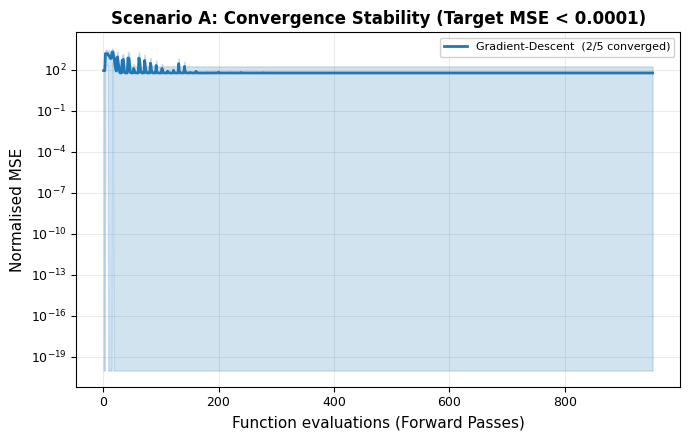

─── Scenario A: Best Optimised Quadrupole Currents per Method ───
Method                     Best MSE      I (A)     I2 (A)
──────────────────────────────────────────────────────────
  Gradient-Descent       4.0257e-12     0.7471     0.5802

  Reference FELsim S1 currents: I=0.8218 A,  I2=1.0430 A

  Overall best across all methods/runs:
    Method: Gradient-Descent,  MSE=4.0257e-12
    I=0.74713 A,  I2=0.58021 A
time: 8min 28s (started: 2026-05-29 13:49:32 -10:00)


In [13]:
%load_ext autotime
import numpy as np
from scipy.optimize import OptimizeResult

# ── Custom scipy-compatible optimizer (callable `method`) ───────────────────────
def _bounds_arrays(bounds, n):
    """Convert scipy bounds into lower/upper numpy arrays."""
    if bounds is None:
        return np.full(n, -np.inf), np.full(n, np.inf)
    if hasattr(bounds, "lb") and hasattr(bounds, "ub"):
        lo = np.asarray(bounds.lb, dtype=float)
        hi = np.asarray(bounds.ub, dtype=float)
    else:
        lo = np.array([(-np.inf if b[0] is None else b[0]) for b in bounds], dtype=float)
        hi = np.array([( np.inf if b[1] is None else b[1]) for b in bounds], dtype=float)
    return np.broadcast_to(lo, n).copy(), np.broadcast_to(hi, n).copy()

def _scalar_fun(fun, x, args):
    """Evaluate scipy-style fun(x, *args) as a finite scalar when possible."""
    value = fun(np.asarray(x, dtype=float), *args)
    if hasattr(value, "item"):
        value = value.item()
    value = float(value)
    return value if np.isfinite(value) else np.inf

def _num_grad_forward(fun, x, f0, lo, hi, args=(), eps=1e-6):
    """Bound-aware one-sided finite-difference gradient."""
    g = np.zeros_like(x, dtype=float)
    nfev = 0

    for i in range(len(x)):
        h = eps * max(1.0, abs(x[i]))
        xp = x.copy()
        xp[i] = min(x[i] + h, hi[i])
        hp = xp[i] - x[i]

        if hp > 0.0:
            fp = _scalar_fun(fun, xp, args)
            nfev += 1
            if np.isfinite(fp):
                g[i] = (fp - f0) / hp
                continue

        xm = x.copy()
        xm[i] = max(x[i] - h, lo[i])
        hm = x[i] - xm[i]

        if hm > 0.0:
            fm = _scalar_fun(fun, xm, args)
            nfev += 1
            if np.isfinite(fm):
                g[i] = (f0 - fm) / hm

    return g, nfev

def minimize_gradient_descent(fun, x0, args=(), bounds=None, learning_rate=0.5,
                              maxiter=200, gtol=1e-9, ftol=1e-12, eps=1e-6,
                              maxls=40, c1=1e-4, callback=None, **kwargs):
    """Projected gradient descent with Armijo backtracking for bound constraints."""
    args = tuple(args) if isinstance(args, (tuple, list)) else (args,)
    x = np.asarray(x0, dtype=float).copy()
    lo, hi = _bounds_arrays(bounds, len(x))
    x = np.clip(x, lo, hi)

    f = _scalar_fun(fun, x, args)
    nfev = 1
    nit = 0
    g = np.full_like(x, np.nan, dtype=float)
    success = False
    status = 1
    message = "maximum iterations reached"

    if not np.isfinite(f):
        return OptimizeResult(x=x, fun=float(f), jac=g, nfev=nfev, nit=nit,
                              success=False, status=2,
                              message="initial objective is not finite")

    for _ in range(maxiter):
        g, ng = _num_grad_forward(fun, x, f, lo, hi, args=args, eps=eps)
        nfev += ng

        projected_step = np.clip(x - g, lo, hi) - x
        if np.linalg.norm(projected_step, ord=np.inf) < gtol:
            success = True
            status = 0
            message = "projected gradient tolerance reached"
            break

        step = learning_rate
        accepted = False
        for _ in range(maxls):
            xn = np.clip(x - step * g, lo, hi)
            d = xn - x
            if np.linalg.norm(d, ord=np.inf) == 0.0:
                step *= 0.5
                continue

            fn = _scalar_fun(fun, xn, args)
            nfev += 1
            if np.isfinite(fn) and fn <= f + c1 * np.dot(g, d):
                accepted = True
                break
            step *= 0.5

        if not accepted:
            status = 2
            message = "line search failed to find a lower objective"
            break

        nit += 1
        if callback is not None:
            callback(xn)

        if abs(f - fn) <= ftol * max(1.0, abs(f)):
            x, f = xn, fn
            success = True
            status = 0
            message = "relative function improvement below ftol"
            break

        x, f = xn, fn

    return OptimizeResult(x=x, fun=float(f), jac=g, nfev=nfev, nit=nit,
                          success=bool(success), status=status, message=message)

METHODS_GD = [
    (minimize_gradient_descent, None, "Gradient-Descent"),
]

results_GD, df_GD, summary_GD = run_scenario_A(
    CURRENT_BOUNDS,
    EPSILON,
    N_RUNS_A,
    REF_I,
    A_OBJ,
    A_BEAMLINE_LEN,
    METHODS_GD,
 )
display_results(results_GD)

# Newton's method
Damped Newton's method (finite-difference gradient + Hessian, Levenberg
regularisation, Armijo line search) run through the **same** benchmark pipeline.

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime

▶ Scenario A — Newton  (5 runs)
  Newton                  run 1/5  MSE=8.298e-14  nit=12  nfev=206  t=41.31s
  Newton                  run 2/5  MSE=5.308e-02  nit=50  nfev=891  t=215.31s
  Newton                  run 3/5  MSE=2.850e-12  nit=31  nfev=705  t=185.46s
  Newton                  run 4/5  MSE=1.583e-13  nit=7   nfev=195  t=46.42s
  Newton                  run 5/5  MSE=8.122e-15  nit=42  nfev=757  t=161.09s

 🎯 SCENARIO A: Robustness (Tol < 0.0001) & Discovered Physics State vs Reference
method_tag conv_rate nit_mean wall_time_mean final_mse_mean I_1_ref    I_1    I_3_ref    I_3    alpha_x   alpha_y 
  Newton      80%      28.4     129.920 s       1.06e-02    0.8218 A 0.2810 A 1.0430 A 0.2678 A 1.96e-08 -1.26e-07


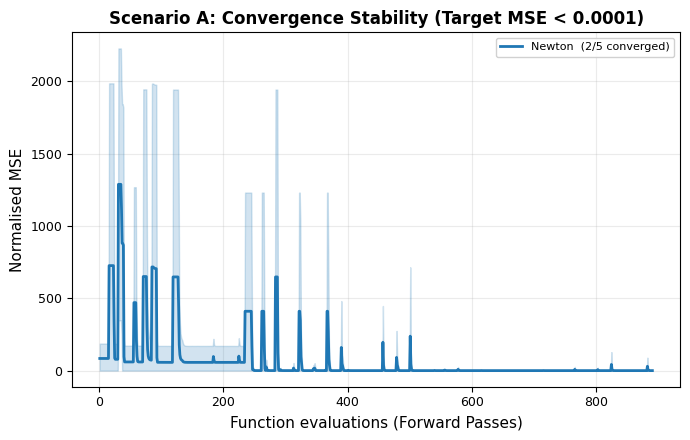

─── Scenario A: Best Optimised Quadrupole Currents per Method ───
Method                     Best MSE      I (A)     I2 (A)
──────────────────────────────────────────────────────────
  Newton                 8.1224e-15     0.2810     0.2678

  Reference FELsim S1 currents: I=0.8218 A,  I2=1.0430 A

  Overall best across all methods/runs:
    Method: Newton,  MSE=8.1224e-15
    I=0.28103 A,  I2=0.26778 A
time: 10min 50s (started: 2026-05-29 13:59:44 -10:00)


In [16]:
%load_ext autotime
import numpy as np
from scipy.optimize import OptimizeResult

def _num_grad_central(fun, x, f0, lo, hi, args=(), eps=1e-5):
    """Bound-aware central-difference gradient with one-sided fallbacks."""
    g = np.zeros_like(x, dtype=float)
    nfev = 0

    for i in range(len(x)):
        h = eps * max(1.0, abs(x[i]))
        xp = x.copy()
        xm = x.copy()
        xp[i] = min(x[i] + h, hi[i])
        xm[i] = max(x[i] - h, lo[i])
        hp = xp[i] - x[i]
        hm = x[i] - xm[i]

        fp = fm = np.nan
        if hp > 0.0:
            fp = _scalar_fun(fun, xp, args)
            nfev += 1
        if hm > 0.0:
            fm = _scalar_fun(fun, xm, args)
            nfev += 1

        if hp > 0.0 and hm > 0.0 and np.isfinite(fp) and np.isfinite(fm):
            g[i] = (fp - fm) / (hp + hm)
        elif hp > 0.0 and np.isfinite(fp):
            g[i] = (fp - f0) / hp
        elif hm > 0.0 and np.isfinite(fm):
            g[i] = (f0 - fm) / hm

    return g, nfev

def _num_hess_from_grad(fun, x, g0, lo, hi, args=(), eps=1e-4, grad_eps=1e-5):
    """Finite-difference Hessian built from the same bound-aware gradient helper."""
    n = len(x)
    hess = np.zeros((n, n), dtype=float)
    nfev = 0

    for j in range(n):
        h = eps * max(1.0, abs(x[j]))
        xp = x.copy()
        xp[j] = min(x[j] + h, hi[j])
        hp = xp[j] - x[j]

        if hp > 0.0:
            fp = _scalar_fun(fun, xp, args)
            gp, ng = _num_grad_central(fun, xp, fp, lo, hi, args=args, eps=grad_eps)
            nfev += ng + 1
            hess[:, j] = (gp - g0) / hp
            continue

        xm = x.copy()
        xm[j] = max(x[j] - h, lo[j])
        hm = x[j] - xm[j]
        if hm > 0.0:
            fm = _scalar_fun(fun, xm, args)
            gm, ng = _num_grad_central(fun, xm, fm, lo, hi, args=args, eps=grad_eps)
            nfev += ng + 1
            hess[:, j] = (g0 - gm) / hm

    return 0.5 * (hess + hess.T), nfev

def _regularized_newton_direction(hess, grad, reg=1e-6, max_reg_tries=8):
    """Return a descent Newton direction, falling back to steepest descent."""
    eye = np.eye(len(grad))
    damping = reg

    for _ in range(max_reg_tries):
        try:
            direction = -np.linalg.solve(hess + damping * eye, grad)
        except np.linalg.LinAlgError:
            damping *= 10.0
            continue

        if np.all(np.isfinite(direction)) and np.dot(grad, direction) < 0.0:
            return direction, damping
        damping *= 10.0

    return -grad, None

def _projected_armijo_step(fun, x, f, grad, direction, lo, hi, args=(),
                           step0=1.0, maxls=40, c1=1e-4):
    """Backtracking line search using the projected trial point as the actual step."""
    step = step0
    nfev = 0

    for _ in range(maxls):
        xn = np.clip(x + step * direction, lo, hi)
        actual_step = xn - x
        descent = np.dot(grad, actual_step)

        if np.linalg.norm(actual_step, ord=np.inf) == 0.0 or descent >= 0.0:
            step *= 0.5
            continue

        fn = _scalar_fun(fun, xn, args)
        nfev += 1
        if np.isfinite(fn) and fn <= f + c1 * descent:
            return True, xn, fn, nfev, step

        step *= 0.5

    return False, x, f, nfev, 0.0

def minimize_newton(fun, x0, args=(), bounds=None, maxiter=50, gtol=1e-9,
                    ftol=1e-12, eps=1e-5, hess_eps=None, reg=1e-6,
                    maxls=40, c1=1e-4, callback=None, **kwargs):
    """Damped projected Newton method with finite-difference gradient and Hessian."""
    args = tuple(args) if isinstance(args, (tuple, list)) else (args,)
    x = np.asarray(x0, dtype=float).copy()
    lo, hi = _bounds_arrays(bounds, len(x))
    x = np.clip(x, lo, hi)

    f = _scalar_fun(fun, x, args)
    nfev = 1
    nit = 0
    grad = np.full_like(x, np.nan, dtype=float)
    hess = np.full((len(x), len(x)), np.nan, dtype=float)
    success = False
    status = 1
    message = "maximum iterations reached"

    if not np.isfinite(f):
        return OptimizeResult(x=x, fun=float(f), jac=grad, hess=hess, nfev=nfev,
                              nit=nit, success=False, status=2,
                              message="initial objective is not finite")

    hess_eps = max(10.0 * eps, 1e-4) if hess_eps is None else hess_eps

    for _ in range(maxiter):
        grad, ng = _num_grad_central(fun, x, f, lo, hi, args=args, eps=eps)
        nfev += ng

        projected_step = np.clip(x - grad, lo, hi) - x
        if np.linalg.norm(projected_step, ord=np.inf) < gtol:
            success = True
            status = 0
            message = "projected gradient tolerance reached"
            break

        hess, nh = _num_hess_from_grad(
            fun, x, grad, lo, hi, args=args, eps=hess_eps, grad_eps=eps
        )
        nfev += nh

        direction, damping = _regularized_newton_direction(hess, grad, reg=reg)
        accepted, xn, fn, used, step = _projected_armijo_step(
            fun, x, f, grad, direction, lo, hi, args=args, step0=1.0, maxls=maxls, c1=c1
        )
        nfev += used

        if not accepted and damping is not None:
            accepted, xn, fn, used, step = _projected_armijo_step(
                fun, x, f, grad, -grad, lo, hi, args=args,
                step0=1.0, maxls=maxls, c1=c1
            )
            nfev += used

        if not accepted:
            status = 2
            message = "line search failed to find a lower objective"
            break

        nit += 1
        if callback is not None:
            callback(xn)

        if abs(f - fn) <= ftol * max(1.0, abs(f)):
            x, f = xn, fn
            success = True
            status = 0
            message = "relative function improvement below ftol"
            break

        x, f = xn, fn

    return OptimizeResult(x=x, fun=float(f), jac=grad, hess=hess, nfev=nfev,
                          nit=nit, success=bool(success), status=status,
                          message=message)

METHODS_NEWTON = [
    (minimize_newton, None, "Newton"),
]

results_Newton, df_Newton, summary_Newton = run_scenario_A(
    CURRENT_BOUNDS,
    EPSILON,
    N_RUNS_A,
    REF_I,
    A_OBJ,
    A_BEAMLINE_LEN,
    METHODS_NEWTON,
 )
display_results(results_Newton)

# increase seed number and repeat the process above


▶ Scenario A — Nelder-Mead  (5 runs)
  Nelder-Mead             run 1/5  MSE=2.743e-08  nit=39  nfev=77   t=15.88s
  Nelder-Mead             run 2/5  MSE=3.544e-08  nit=42  nfev=78   t=15.05s
  Nelder-Mead             run 3/5  MSE=6.965e-09  nit=51  nfev=96   t=18.07s
  Nelder-Mead             run 4/5  MSE=3.389e-09  nit=48  nfev=87   t=16.48s
  Nelder-Mead             run 5/5  MSE=1.816e-09  nit=43  nfev=81   t=17.40s

▶ Scenario A — L-BFGS-B  (5 runs)
  L-BFGS-B                run 1/5  MSE=1.718e+00  nit=0   nfev=3    t=0.64s
  L-BFGS-B                run 2/5  MSE=4.583e+02  nit=0   nfev=3    t=0.62s
  L-BFGS-B                run 3/5  MSE=1.095e+03  nit=0   nfev=3    t=0.57s
  L-BFGS-B                run 4/5  MSE=6.034e+02  nit=2   nfev=45   t=9.00s
  L-BFGS-B                run 5/5  MSE=7.698e+02  nit=2   nfev=48   t=8.86s

▶ Scenario A — L-BFGS-B+jac  (5 runs)
  L-BFGS-B                run 1/5  MSE=1.718e+00  nit=0   nfev=3    t=0.50s
  L-BFGS-B                run 2/5  MSE=4.583e+0

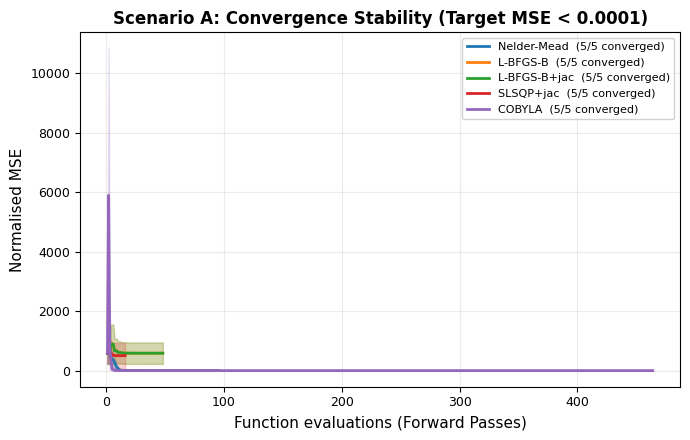

─── Scenario A: Best Optimised Quadrupole Currents per Method ───
Method                     Best MSE      I (A)     I2 (A)
──────────────────────────────────────────────────────────
  Nelder-Mead            1.8157e-09     0.2810     0.2678
  L-BFGS-B               1.7183e+00     0.5135     0.6932
  L-BFGS-B+jac           1.7183e+00     0.5135     0.6932
  SLSQP+jac              1.7188e+00     0.5135     0.6933
  COBYLA                 6.9247e-05     0.9455     1.1826

  Reference FELsim S1 currents: I=0.8218 A,  I2=1.0430 A

  Overall best across all methods/runs:
    Method: Nelder-Mead,  MSE=1.8157e-09
    I=0.28100 A,  I2=0.26776 A

▶ Scenario A — Nelder-Mead  (5 runs)
  Nelder-Mead             run 1/5  MSE=3.999e-08  nit=43  nfev=81   t=16.08s
  Nelder-Mead             run 2/5  MSE=3.245e-09  nit=39  nfev=76   t=15.86s
  Nelder-Mead             run 3/5  MSE=4.257e-09  nit=39  nfev=77   t=15.84s
  Nelder-Mead             run 4/5  MSE=5.417e-09  nit=33  nfev=63   t=13.01s
  Nelder-M

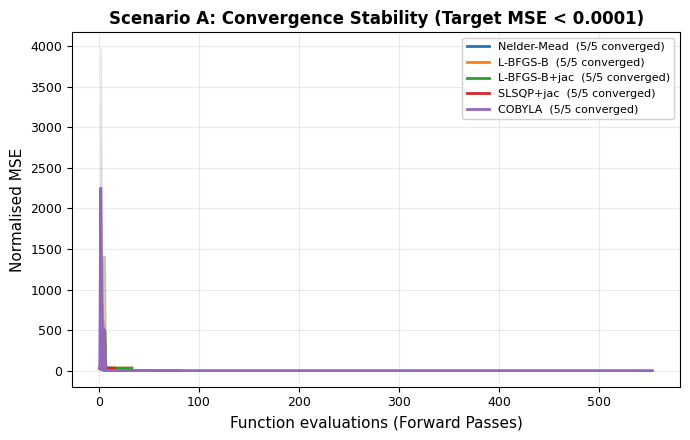

─── Scenario A: Best Optimised Quadrupole Currents per Method ───
Method                     Best MSE      I (A)     I2 (A)
──────────────────────────────────────────────────────────
  Nelder-Mead            3.2455e-09     0.9399     1.1796
  L-BFGS-B               3.2114e+00     0.4273     0.6971
  L-BFGS-B+jac           3.2114e+00     0.4273     0.6971
  SLSQP+jac              3.2114e+00     0.4273     0.6971
  COBYLA                 6.5737e-06     0.7464     0.5798

  Reference FELsim S1 currents: I=0.8218 A,  I2=1.0430 A

  Overall best across all methods/runs:
    Method: Nelder-Mead,  MSE=3.2455e-09
    I=0.93989 A,  I2=1.17957 A

▶ Scenario A — Nelder-Mead  (5 runs)
  Nelder-Mead             run 1/5  MSE=2.910e-09  nit=53  nfev=101  t=21.62s
  Nelder-Mead             run 2/5  MSE=4.077e-08  nit=38  nfev=73   t=13.86s
  Nelder-Mead             run 3/5  MSE=1.438e-09  nit=45  nfev=82   t=15.37s
  Nelder-Mead             run 4/5  MSE=1.505e-09  nit=49  nfev=95   t=18.01s
  Nelder-M

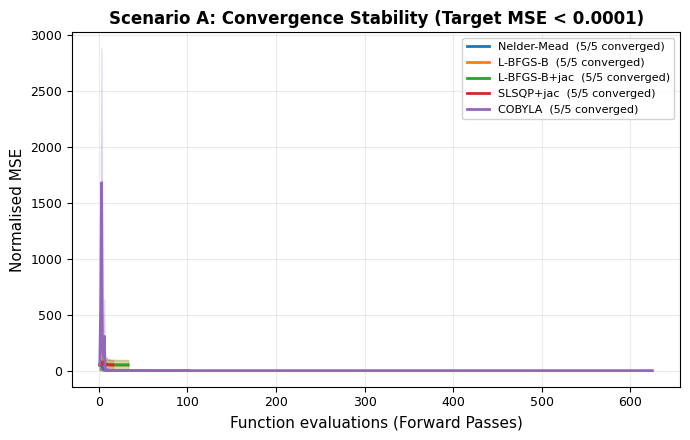

─── Scenario A: Best Optimised Quadrupole Currents per Method ───
Method                     Best MSE      I (A)     I2 (A)
──────────────────────────────────────────────────────────
  Nelder-Mead            1.4379e-09     0.8663     1.1388
  L-BFGS-B               1.9737e+00     0.7078     0.7764
  L-BFGS-B+jac           1.9737e+00     0.7078     0.7764
  SLSQP+jac              1.9737e+00     0.7078     0.7764
  COBYLA                 1.0319e-07     0.2812     0.2679

  Reference FELsim S1 currents: I=0.8218 A,  I2=1.0430 A

  Overall best across all methods/runs:
    Method: Nelder-Mead,  MSE=1.4379e-09
    I=0.86628 A,  I2=1.13881 A

▶ Scenario A — Nelder-Mead  (5 runs)
  Nelder-Mead             run 1/5  MSE=1.368e-08  nit=46  nfev=90   t=19.97s
  Nelder-Mead             run 2/5  MSE=5.292e-09  nit=54  nfev=103  t=22.53s
  Nelder-Mead             run 3/5  MSE=3.300e-09  nit=37  nfev=72   t=15.89s
  Nelder-Mead             run 4/5  MSE=2.053e-08  nit=56  nfev=108  t=23.80s
  Nelder-M

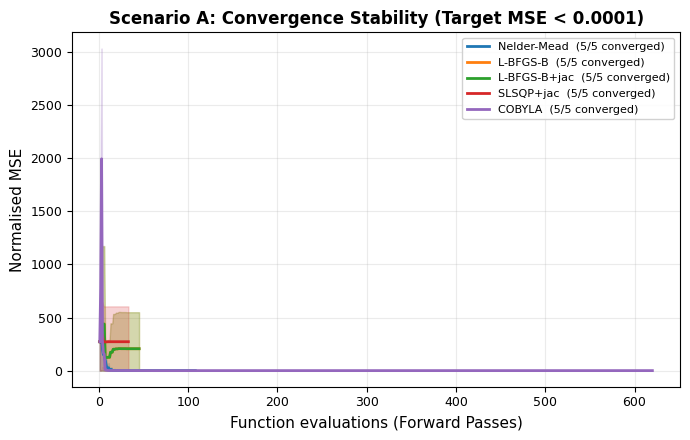

─── Scenario A: Best Optimised Quadrupole Currents per Method ───
Method                     Best MSE      I (A)     I2 (A)
──────────────────────────────────────────────────────────
  Nelder-Mead            3.2362e-09     0.8662     1.1388
  L-BFGS-B               9.9476e+00     0.9576     1.3628
  L-BFGS-B+jac           9.9476e+00     0.9576     1.3628
  SLSQP+jac              2.3681e+01     0.0941     0.4971
  COBYLA                 3.8558e-05     0.2775     0.2645

  Reference FELsim S1 currents: I=0.8218 A,  I2=1.0430 A

  Overall best across all methods/runs:
    Method: Nelder-Mead,  MSE=3.2362e-09
    I=0.86623 A,  I2=1.13878 A

▶ Scenario A — Nelder-Mead  (5 runs)
  Nelder-Mead             run 1/5  MSE=6.070e-09  nit=42  nfev=79   t=20.40s
  Nelder-Mead             run 2/5  MSE=4.070e-09  nit=59  nfev=113  t=21.61s
  Nelder-Mead             run 3/5  MSE=2.555e-08  nit=54  nfev=103  t=19.85s
  Nelder-Mead             run 4/5  MSE=4.338e-09  nit=47  nfev=92   t=29.61s
  Nelder-M

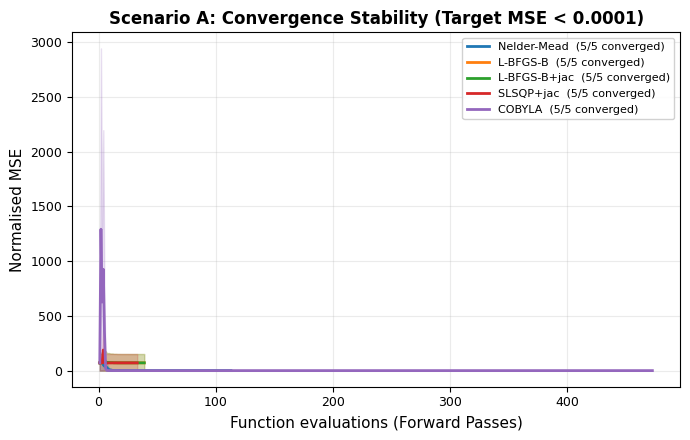

─── Scenario A: Best Optimised Quadrupole Currents per Method ───
Method                     Best MSE      I (A)     I2 (A)
──────────────────────────────────────────────────────────
  Nelder-Mead            4.0695e-09     0.2810     0.2678
  L-BFGS-B               4.7736e+00     0.3613     0.6494
  L-BFGS-B+jac           4.7736e+00     0.3613     0.6494
  SLSQP+jac              4.7736e+00     0.3613     0.6494
  COBYLA                 2.2504e-05     0.9432     1.1814

  Reference FELsim S1 currents: I=0.8218 A,  I2=1.0430 A

  Overall best across all methods/runs:
    Method: Nelder-Mead,  MSE=4.0695e-09
    I=0.28100 A,  I2=0.26776 A
time: 40min 58s (started: 2026-05-29 14:10:34 -10:00)


In [17]:
SEED_SET={12,20,26,30,35}


for seed in SEED_SET:
    results_A, df_A, final_summary = run_scenario_A(CURRENT_BOUNDS, EPSILON, N_RUNS_A, REF_I, A_OBJ, A_BEAMLINE_LEN, METHODS_A, SEED=seed)
    display_results(results_A)